# International Football Match Outcome Prediction
## INFOH410 Project: Comparison of 3 AI Approaches

**Group 14:**
- Amine Bâaj
- Thierno Diallo
- Henock Mbolitumbalani Likoyo

**Goal**: predict the outcome of an international football match (Home win / Draw / Away win) using three different AI techniques:
1. **Naive Bayes**
2. **Random Forest** (introduced through a Decision Tree and Bagging)
3. **Neural Network (MLP)**

---
## 1. Imports

We import the librairies needed.

In [1]:
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, log_loss
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# reproducibility
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)

---
## 2. Loading the dataset

We use the "International Football Results from 1872 to 2026" dataset on Kaggle, a comprehensive collection of nearly 50,000 international football matches national teams.

Source: https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017

### 2.1. Dataset structure

The file `result.csv` contains one row per international match with the following columns:

|Column|Meaning|
|---|---|
|`date`|Date of the match (YYYY-MM-DD)|
|`home_team`|Name of the home team (e.g., "Brazil")|
|`away_team`|Name of the away team (e.g., "Germany")|
|`home_score`|Goals scored by the home team|
|`away_score`|Goals scored by the away team|
|`tournament`|Type of competition (e.g., "FIFA World Cup", "Friendly", "UEFA Euro qualification")|
|`city`|City where the match was played|
|`country`|Country where the match was played|
|`neutral`|`True` if played on neutral ground (no home advantage)|

In [2]:
DATA_PATH = '../data/results.csv'

# read the raw files and clean problematic commas (example: Washington, D.C.)
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    content = f.read()

# regex: find any "..., ..." pattern and remove the quotes + internal comma
content_clean = re.sub(r'"([^"]*),\s*([^"]*)"', r'\1 \2', content)

# save the cleaned version to a new file
CLEAN_PATH = '../data/results_clean.csv'
with open(CLEAN_PATH, 'w', encoding='utf-8') as f:
    f.write(content_clean)

# now load the cleaned CSV
df = pd.read_csv(CLEAN_PATH)

# basic info
print(f"Dataset loaded: {df.shape[0]} matches, {df.shape[1]} columns")
print(f"Date range: {df['date'].min()} -> {df['date'].max()}\n")

df.head()

Dataset loaded: 49287 matches, 9 columns
Date range: 1872-11-30 -> 2026-06-27



,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


---
## 3. Data analysis

Before building any model, we explore the dataset to understand its structure, detect anomalies and motivate our preprocessing decisions.

### 3.1. Basic statistics and missing values

We first convert the `date` column to a proper datetime type, sort the data chronologically and check for missing values or anomalies.

In [3]:
# convert date column to datetime type 
df['date'] = pd.to_datetime(df['date'])

# sort chronoligically 
df = df.sort_values('date').reset_index(drop=True)

# check column types
print("Column types:")
print(df.dtypes)

# check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

Column types:
date          datetime64[ns]
home_team             object
away_team             object
home_score           float64
away_score           float64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object

Missing values per column:
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64


### 3.2. Cleaning: removing matches without scores

The dataset contains 72 matches with missing scores, these are future matches scheduled but not played (e.g., upcoming 2026 World Cup).

In [4]:
# count rows before cleaning
n_before = len(df)

# remove matches with missing scores
df = df.dropna(subset=['home_score', 'away_score']).reset_index(drop=True)

# convert scores back to integers
df['home_score'] = df['home_score'].astype(int)
df['away_score'] = df['away_score'].astype(int)

n_after = len(df)

print(f"removed {n_before - n_after} matches with missing socres")
print(f"Final dataset: {n_after} matches")
print("\nUpdated column types:")
print(df.dtypes)

removed 72 matches with missing socres
Final dataset: 49215 matches

Updated column types:
date          datetime64[ns]
home_team             object
away_team             object
home_score             int64
away_score             int64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object


### 3.3. Temporal coverage

The dataset covers than 150 years of international football. We analyze how matches are distributed over time on a relevant time window for our models.

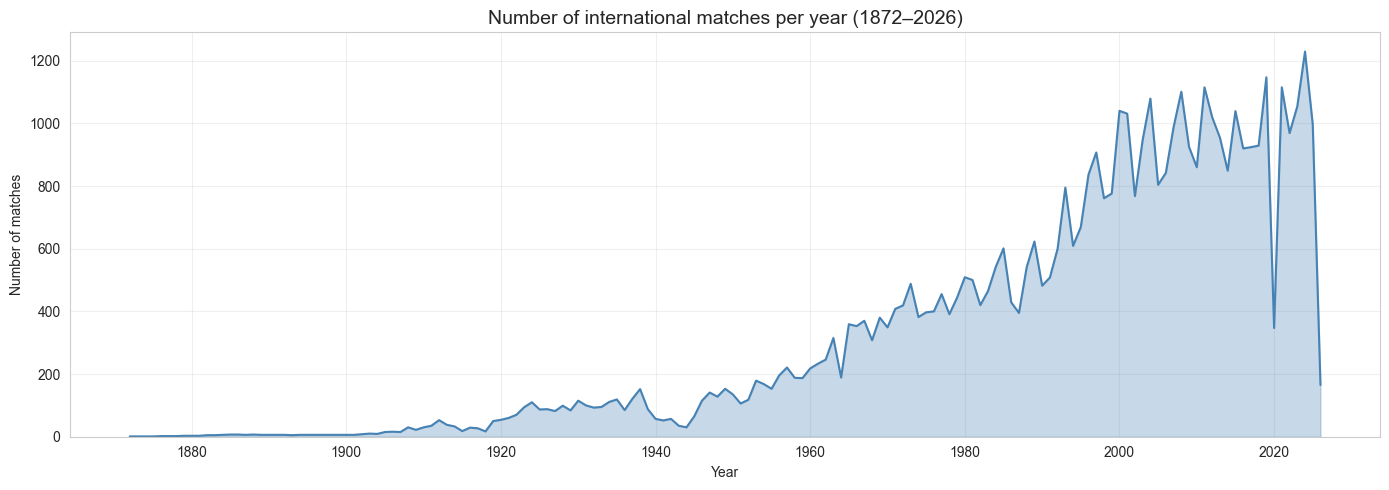

Total years covered: 154
Average matches per year: 318
Year with most matches: 2024 (1229 matches)
Year with fewest matches: 1872 (1 matches)


In [5]:
# extract year from each match
df['year'] = df['date'].dt.year

# count matches per year
matches_per_year = df.groupby('year').size()

# plot the distribution
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(matches_per_year.index, matches_per_year.values, color='steelblue', linewidth=1.5)
ax.fill_between(matches_per_year.index, matches_per_year.values, alpha=0.3, color='steelblue')

ax.set_title("Number of international matches per year (1872–2026)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Number of matches")
ax.set_ylim(0,)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total years covered: {df['year'].max() - df['year'].min()}")
print(f"Average matches per year: {matches_per_year.mean():.0f}")
print(f"Year with most matches: {matches_per_year.idxmax()} ({matches_per_year.max()} matches)")
print(f"Year with fewest matches: {matches_per_year.idxmin()} ({matches_per_year.min()} matches)")

### 3.4. Distribution of match outcomes

We now derive our target variable `result` from the scores:
- `H` if `home_score > away_score` (Home win)
- `D` if `home_score == away_score` (Draw)
- `A` if `home_score < away_score` (Away win)

Analyzing the distribution of `result`reveals two phenomena:
1. **Home advantage:** teams playing at home tend to win more often
2. **Class imbalance:** draw are less frequent than wins

In [6]:
# derive the target variable from the scores
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'H'
    elif row['home_score'] < row['away_score']:
        return 'A'
    else:
        return 'D'

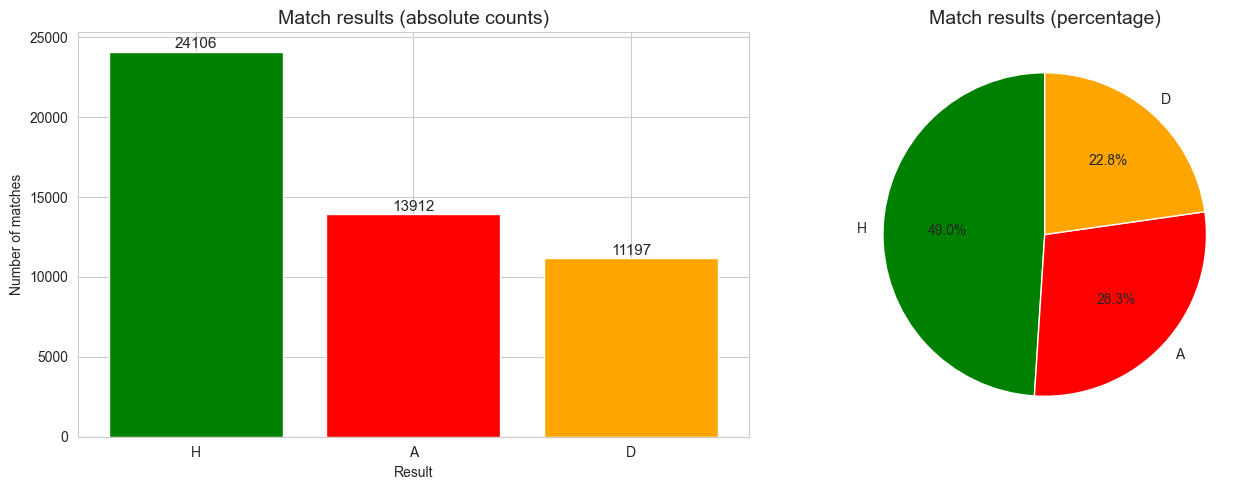

In [7]:
result_values = ['H', 'D', 'A']

df['result'] = df.apply(get_result, axis=1)

# count the distribution
result_counts = df['result'].value_counts()
result_percentage = df['result'].value_counts(normalize=True) * 100

# plot the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar chart
colors = {'H': 'green', 'D': 'orange', 'A': 'red'}
axes[0].bar(result_counts.index, result_counts.values, color=[colors[r] for r in result_counts.index])
axes[0].set_title("Match results (absolute counts)", fontsize=14)
axes[0].set_xlabel("Result")
axes[0].set_ylabel("Number of matches")
for i, (r, v) in enumerate(result_counts.items()):
    axes[0].text(i, v + 200, f"{v}", ha='center', fontsize=11)

# pie chart
axes[1].pie(result_percentage.values, labels=result_percentage.index, colors=[colors[r] for r in result_percentage.index], autopct='%1.1f%%', startangle=90)
axes[1].set_title("Match results (percentage)", fontsize=14)

plt.tight_layout()
plt.show()

### 3.5. Impact of neutral ground on home advantage

When a match is played on neutral ground (e.g., World Cup, continental cup), the labels "home" and "away" are arbitrary, there is no real home advantage. We expect the H/D/A distribution to be much more balanced for these matches. We should treat neutral matches differently to avoid teaching our models a false home advantage in these cases.

Matches with home advantage: 36239 (73.6%)
Matches on neutral ground: 12976 (26.4%)


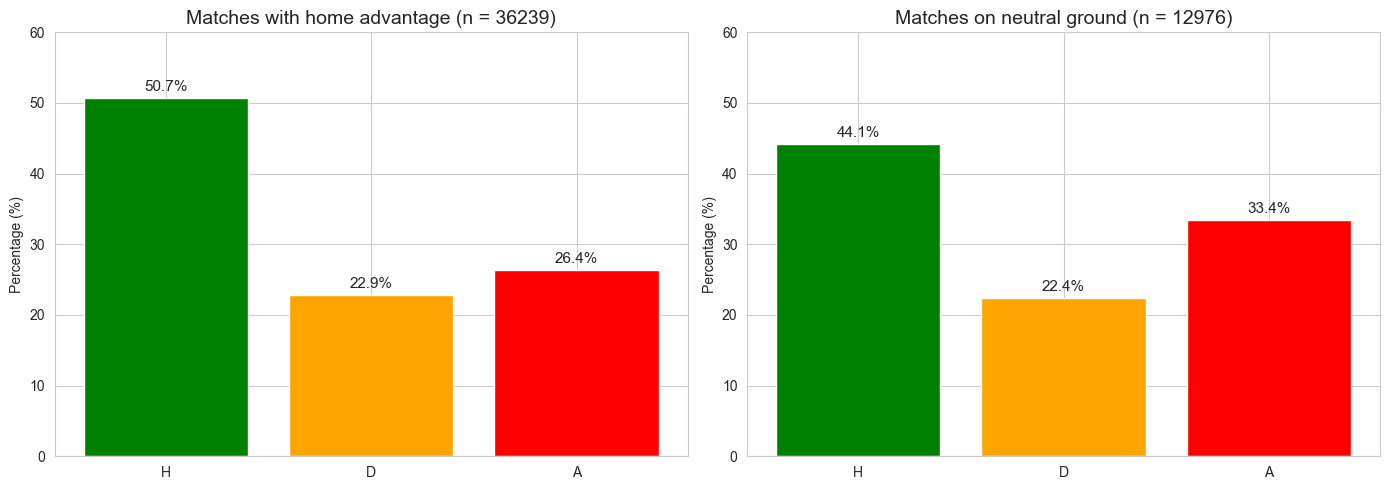

In [8]:
# split the dataset into neutral and non-neutral matches
df_home_advantage = df[df['neutral'] == False]
df_neutral = df[df['neutral'] == True]

print(f"Matches with home advantage: {len(df_home_advantage)} ({len(df_home_advantage)/len(df)*100:.1f}%)")
print(f"Matches on neutral ground: {len(df_neutral)} ({len(df_neutral)/len(df)*100:.1f}%)")

# compute distributions
percentage_home_adv = df_home_advantage['result'].value_counts(normalize=True) * 100
percentage_neutral = df_neutral['result'].value_counts(normalize=True) * 100

# comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# non-neutral
axes[0].bar(result_values, [percentage_home_adv.get(r, 0) for r in result_values], color=[colors[r] for r in result_values])
axes[0].set_title(f"Matches with home advantage (n = {len(df_home_advantage)})", fontsize=14)
axes[0].set_ylabel("Percentage (%)")
axes[0].set_ylim(0, 60)
for i, r in enumerate(result_values):
    axes[0].text(i, percentage_home_adv.get(r, 0) + 1, f"{percentage_home_adv.get(r, 0):.1f}%", ha='center', fontsize=11)

# neutral
axes[1].bar(result_values, [percentage_neutral.get(r, 0) for r in result_values], color=[colors[r] for r in result_values])
axes[1].set_title(f"Matches on neutral ground (n = {len(df_neutral)})", fontsize=14)
axes[1].set_ylabel("Percentage (%)")
axes[1].set_ylim(0, 60)
for i, r in enumerate(result_values):
    axes[1].text(i, percentage_neutral.get(r, 0) + 1, f"{percentage_neutral.get(r, 0):.1f}%", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

### 3.6. Goal distribution

We analyze how many goals are typically scored in international matches.

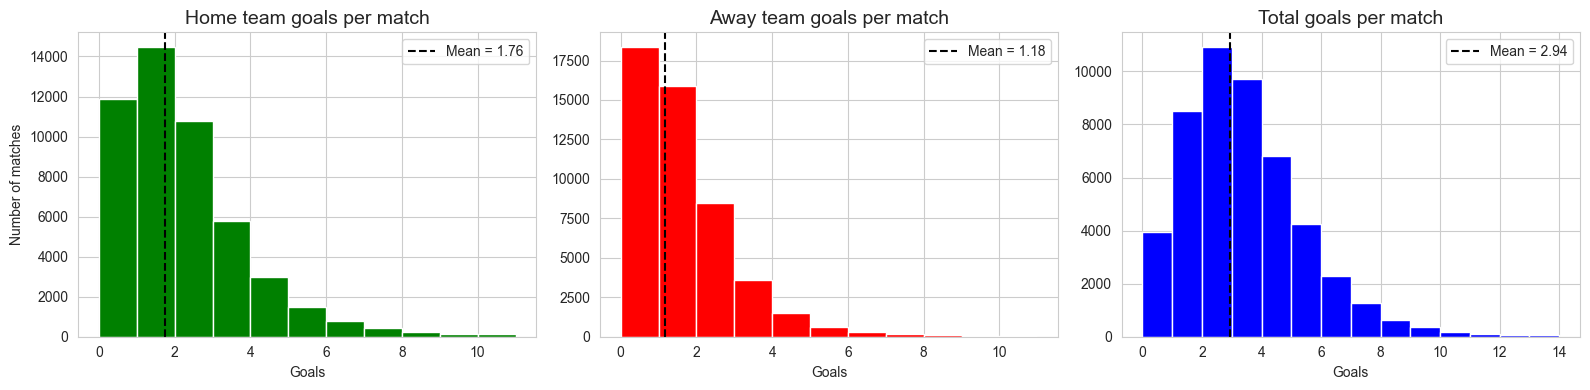


Most extreme matches:
      date home_team      away_team  home_score  away_score  total_goals
2001-04-11 Australia American Samoa          31           0           31
1971-09-13    Tahiti   Cook Islands          30           0           30
1979-08-30      Fiji       Kiribati          24           0           24
2001-04-09 Australia          Tonga          22           0           22
2006-11-24     Sápmi         Monaco          21           1           22


In [9]:
# total goals per match
df['total_goals'] = df['home_score'] + df['away_score']

# home vs away goals
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# home goals
axes[0].hist(df['home_score'], bins=range(0, 12), color='green')
axes[0].set_title("Home team goals per match", fontsize=14)
axes[0].set_xlabel("Goals")
axes[0].set_ylabel("Number of matches")
axes[0].axvline(df['home_score'].mean(), color='black', linestyle='--', label=f"Mean = {df['home_score'].mean():.2f}")
axes[0].legend()

# away goals
axes[1].hist(df['away_score'], bins=range(0, 12), color='red')
axes[1].set_title("Away team goals per match", fontsize=14)
axes[1].set_xlabel("Goals")
axes[1].axvline(df['away_score'].mean(), color='black', linestyle='--', label=f"Mean = {df['away_score'].mean():.2f}")
axes[1].legend()

# total goals
axes[2].hist(df['total_goals'], bins=range(0, 15), color='blue')
axes[2].set_title("Total goals per match", fontsize=14)
axes[2].set_xlabel("Goals")
axes[2].axvline(df['total_goals'].mean(), color='black', linestyle='--', label=f"Mean = {df['total_goals'].mean():.2f}")
axes[2].legend()

plt.tight_layout()
plt.show()

# stats
print(f"\nMost extreme matches:")
top = df.nlargest(5, 'total_goals')[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'total_goals']]
print(top.to_string(index=False))

### 3.7. Most active teams and tournaments

We finally examine which teams play the most matches and what kinds of tournaments dominate the dataset.

Total unique teams in dataset: 333
Median matches per team: 231


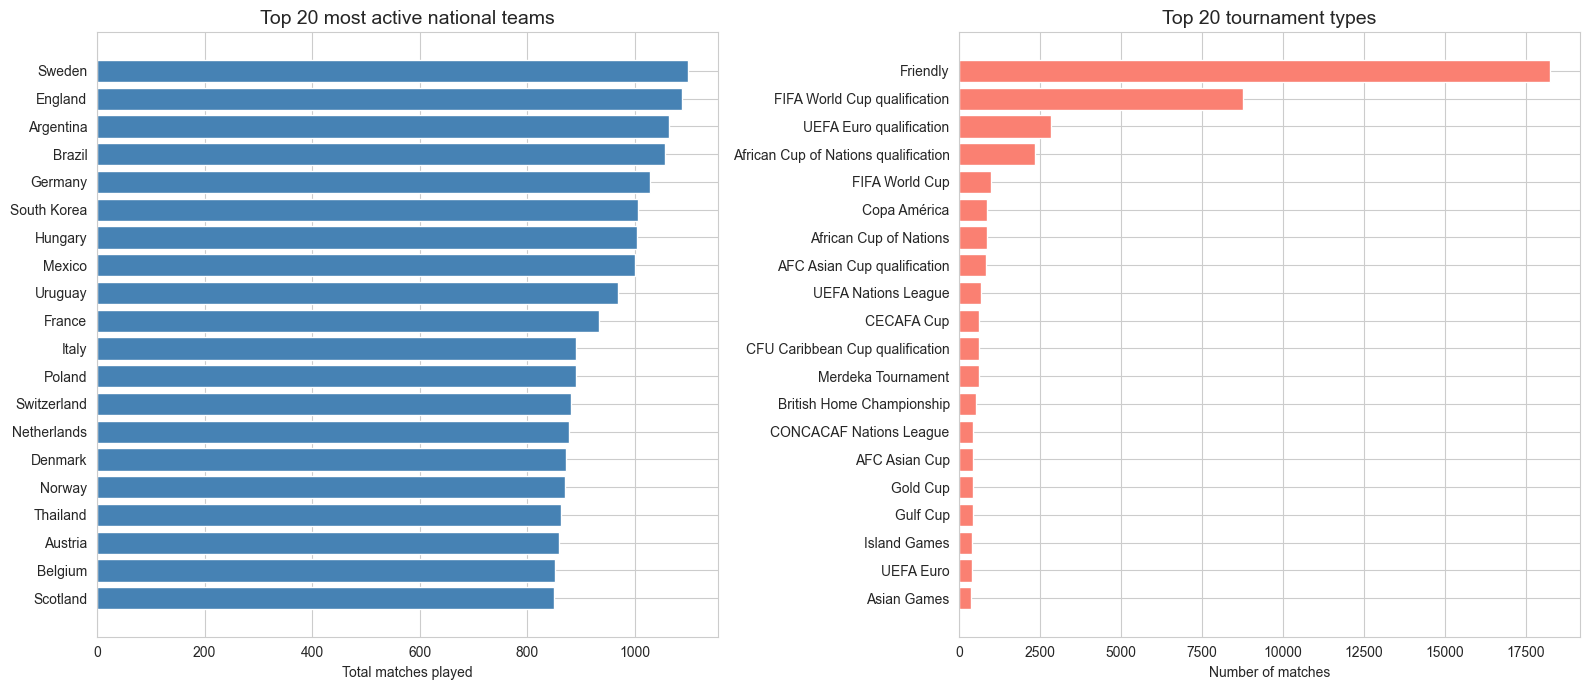


Friendly matches: 18252 (37.1%)
Competitive matches: 30963 (62.9%)


In [10]:
# combine home and away appearances to count total matches per team
home_counts = df['home_team'].value_counts()
away_counts = df['away_team'].value_counts()
all_appearances = home_counts.add(away_counts, fill_value=0).sort_values(ascending=False)

print(f"Total unique teams in dataset: {len(all_appearances)}")
print(f"Median matches per team: {all_appearances.median():.0f}")

# plot top teams + top tournaments
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# top 20 most active national teams
top_teams = all_appearances.head(20)
axes[0].barh(top_teams.index[::-1], top_teams.values[::-1], color='steelblue')
axes[0].set_title("Top 20 most active national teams", fontsize=14)
axes[0].set_xlabel("Total matches played")

# top 20 tournament types
top_tournaments = df['tournament'].value_counts().head(20)
axes[1].barh(top_tournaments.index[::-1], top_tournaments.values[::-1], color='salmon')
axes[1].set_title("Top 20 tournament types", fontsize=14)
axes[1].set_xlabel("Number of matches")

plt.tight_layout()
plt.show()

# summary about friendlies vs competitive
n_friendly  = (df['tournament'] == 'Friendly').sum()
n_competitive = len(df) - n_friendly
print(f"\nFriendly matches: {n_friendly} ({n_friendly/len(df)*100:.1f}%)")
print(f"Competitive matches: {n_competitive} ({n_competitive/len(df)*100:.1f}%)")

---
## 4. Building predictive features

Now that we understand the data, we will transform it into a format suitable for models. Recall our strategy: each match is encoded as a vector of statistical features computed from the recent history of both teams.

### 4.1. Temporal filtering

The dataset covers 1872–2026, but football has changed enormously over 150 years (rules, tactics, etc). Including very old matches would teach our models patterns that no longer apply. We restrict the analysis to matches from 2000 onwards. This Ensures homogeneous data from the modern football era.

In [11]:
# keep only matches from 2000-01-01 onwards
START_YEAR = 2000
n_before = len(df)

df = df[df['date'] >= f'{START_YEAR}-01-01'].reset_index(drop=True)

n_after = len(df)

print(f"Filter applied: matches from {START_YEAR} onwards")
print(f"  Before: {n_before} matches")
print(f"  After: {n_after} matches ({n_after/n_before*100:.1f}% kept)")
print(f"\nDate range: {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"\nNew result distribution:")
print(df['result'].value_counts(normalize=True).round(3))

Filter applied: matches from 2000 onwards
  Before: 49215 matches
  After: 25157 matches (51.1% kept)

Date range: 2000-01-04 -> 2026-03-31

New result distribution:
result
H    0.481
A    0.286
D    0.233
Name: proportion, dtype: float64


### 4.2. Recent team performance

For each match, we want to know how each team has been performing recently, before the match takes place. This is the most important set of features in our model.

#### 4.2.1. Function to retrieve a team's history

We define a function that given a team and a date returns the team's last N matches before that date.

In [12]:
def get_team_last_matches(df, team, before_date, n=10):
    mask = ((df['home_team'] == team) | (df['away_team'] == team)) & (df['date'] < before_date)
    history = df.loc[mask].sort_values('date').tail(n)
    return history


# test: get Brazil's last 10 matches before the 2014 World Cup final
test_history = get_team_last_matches(df, 'Brazil', pd.Timestamp('2014-07-13'), n=10)
print("Brazil's last 10 matches before the 2014 World Cup final:")
print(test_history[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament']].to_string(index=False))

Brazil's last 10 matches before the 2014 World Cup final:
      date    home_team   away_team  home_score  away_score     tournament
2014-03-05 South Africa      Brazil           0           5       Friendly
2014-06-03       Brazil      Panama           4           0       Friendly
2014-06-06       Brazil      Serbia           1           0       Friendly
2014-06-12       Brazil     Croatia           3           1 FIFA World Cup
2014-06-17       Brazil      Mexico           0           0 FIFA World Cup
2014-06-23       Brazil    Cameroon           4           1 FIFA World Cup
2014-06-28       Brazil       Chile           1           1 FIFA World Cup
2014-07-04       Brazil    Colombia           2           1 FIFA World Cup
2014-07-08       Brazil     Germany           1           7 FIFA World Cup
2014-07-12       Brazil Netherlands           0           3 FIFA World Cup


#### 4.2.2. Compute aggregated statistics from a team's history

Given a list of past matches for a team, we compute summary statistics.

In [13]:
def compute_team_stats(history, team):

    if len(history) == 0:
        # no history available -> return zeros
        return {'matches_played': 0, 'wins': 0, 'draws': 0, 'losses': 0, 'goals_scored': 0.0, 'goals_conceded': 0.0, 'goal_diff': 0.0, 'points': 0.0}

    wins = draws = losses = 0
    goals_scored = goals_conceded = 0

    for _, m in history.iterrows():
        # determine whether team was home or away in this past match
        if m['home_team'] == team:
            scored = m['home_score']
            conceded = m['away_score']
        else:
            scored = m['away_score']
            conceded = m['home_score']

        goals_scored   += scored
        goals_conceded += conceded

        # did the team win, draw, or lose ?
        if scored > conceded:
            wins += 1
        elif scored < conceded:
            losses += 1
        else:
            draws += 1

    n = len(history)
    return {
        'matches_played': n,
        'wins': wins,
        'draws': draws,
        'losses': losses,
        'goals_scored': goals_scored / n,
        'goals_conceded': goals_conceded / n,
        'goal_diff': (goals_scored - goals_conceded) / n,
        'points': (3 * wins + draws) / n
    }


# test on Brazil's pre-2014-final history
stats = compute_team_stats(test_history, 'Brazil')
print("Brazil's stats from the last 10 matches before 2014 final:")
for key, val in stats.items():
    if isinstance(val, float):
        print(f"  {key}: {val:.2f}")
    else:
        print(f"  {key}: {val}")

Brazil's stats from the last 10 matches before 2014 final:
  matches_played: 10
  wins: 6
  draws: 2
  losses: 2
  goals_scored: 2.10
  goals_conceded: 1.40
  goal_diff: 0.70
  points: 2.00


#### 4.2.3. Apply to the entire dataset

We now compute rolling features for every match in the dataset. For each match, we call our two helper functions twice, once for the home team, once for the away team.

For each match, we'll have **16 numerical features**:
- 8 features for the home team (`H_wins`, `H_goals_scored`, ...)
- 8 features for the away team (`A_wins`, `A_goals_scored`, ...)

Plus the original target `result`.

In [14]:
WINDOW_SIZE = 10 # number of past matches to consider

features_list = []

print(f"Computing features for {len(df)} matches...")

for _, row in df.iterrows():
    # get history for both teams
    home_history = get_team_last_matches(df, row['home_team'], row['date'], n=WINDOW_SIZE)
    away_history = get_team_last_matches(df, row['away_team'], row['date'], n=WINDOW_SIZE)

    # compute their stats
    home_stats = compute_team_stats(home_history, row['home_team'])
    away_stats = compute_team_stats(away_history, row['away_team'])

    # build a flat dict for this match
    feature_row = {
        'date': row['date'],
        'home_team': row['home_team'],
        'away_team': row['away_team'],
        'neutral': row['neutral'],
        'tournament': row['tournament'],
        'result': row['result'] # target
    }

    # prefix home stats with H_ and away stats with A_
    for key, val in home_stats.items():
        feature_row[f'H_{key}'] = val

    for key, val in away_stats.items():
        feature_row[f'A_{key}'] = val

    features_list.append(feature_row)

# convert list of dicts to DataFrame
df_features = pd.DataFrame(features_list)

print(f"Features dataframe shape: {df_features.shape}")

df_features.head()

Computing features for 25157 matches...
Features dataframe shape: (25157, 22)


,date,home_team,away_team,neutral,tournament,result,H_matches_played,H_wins,H_draws,H_losses,...,H_goal_diff,H_points,A_matches_played,A_wins,A_draws,A_losses,A_goals_scored,A_goals_conceded,A_goal_diff,A_points
0,2000-01-04,Egypt,Togo,False,Friendly,H,0,0,0,0,...,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0
1,2000-01-07,Tunisia,Togo,False,Friendly,H,0,0,0,0,...,0.0,0.0,1,0,0,1,1.0,2.0,-1.0,0.0
2,2000-01-08,Trinidad and Tobago,Canada,False,Friendly,D,0,0,0,0,...,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0
3,2000-01-09,Ivory Coast,Egypt,False,Friendly,H,0,0,0,0,...,0.0,0.0,1,1,0,0,2.0,1.0,1.0,3.0
4,2000-01-09,Mexico,Iran,True,Friendly,H,0,0,0,0,...,0.0,0.0,0,0,0,0,0.0,0.0,0.0,0.0


### 4.3. Filter matches with insufficient history

The first matches of our filtered dataset (Jan 2000) have no available history because we discarded all matches before 2000. These matches have all features at zero, which would teach our models nothing useful. We require both teams to have at least 5 past matches in their history.

In [15]:
# required minimum number of past matches for both teams
MIN_HISTORY = 5

n_before = len(df_features)

# keep only matches where both teams have at least MIN_HISTORY past games
mask = (df_features['H_matches_played'] >= MIN_HISTORY) & (df_features['A_matches_played'] >= MIN_HISTORY)

df_features = df_features[mask].reset_index(drop=True)

n_after = len(df_features)
print(f"Filtered out matches with insufficient history (< {MIN_HISTORY} past games)")
print(f"  Before: {n_before} matches")
print(f"  After: {n_after} matches ({n_after/n_before*100:.1f}% kept)")

print(f"\nNew date range: {df_features['date'].min().date()} -> {df_features['date'].max().date()}")

print(f"\nResult distribution:")
print(df_features['result'].value_counts(normalize=True).round(3))

print(f"\nMinimum H_matches_played = {df_features['H_matches_played'].min()}")
print(f"Minimum A_matches_played = {df_features['A_matches_played'].min()}")

df_features.head()

Filtered out matches with insufficient history (< 5 past games)
  Before: 25157 matches
  After: 24095 matches (95.8% kept)

New date range: 2000-02-01 -> 2026-03-31

Result distribution:
result
H    0.479
A    0.287
D    0.235
Name: proportion, dtype: float64

Minimum H_matches_played = 5
Minimum A_matches_played = 5


,date,home_team,away_team,neutral,tournament,result,H_matches_played,H_wins,H_draws,H_losses,...,H_goal_diff,H_points,A_matches_played,A_wins,A_draws,A_losses,A_goals_scored,A_goals_conceded,A_goal_diff,A_points
0,2000-02-01,Egypt,Burkina Faso,True,African Cup of Nations,H,5,3,0,2,...,0.2,1.8,5,1,3,1,1.200000,1.400000,-0.200000,1.200000
1,2000-02-07,Egypt,Tunisia,True,African Cup of Nations,A,6,4,0,2,...,0.5,2.0,5,2,1,2,2.000000,1.200000,0.800000,1.400000
2,2000-02-10,Cameroon,Tunisia,True,African Cup of Nations,H,6,2,3,1,...,0.5,1.5,6,3,1,2,1.833333,1.000000,0.833333,1.666667
3,2000-02-12,South Africa,Tunisia,True,African Cup of Nations,D,5,3,1,1,...,0.4,2.0,7,3,1,3,1.571429,1.285714,0.285714,1.428571
4,2000-02-13,Nigeria,Cameroon,False,African Cup of Nations,D,5,4,1,0,...,1.4,2.6,7,3,3,1,1.571429,0.714286,0.857143,1.714286


### 4.4. Encoding non-numerical features

Two of our columns are non-numerical: `neutral` (boolean) and `tournament` (string). We encode them into numbers so the models can use them:

- `neutral` -> `is_neutral` (1 if neutral ground, 0 otherwise)
- `tournament` -> `is_competitive` (1 if competitive, 0 if friendly)

In [16]:
# encode 'neutral' as 0/1
df_features['is_neutral'] = df_features['neutral'].astype(int)

# encode 'tournament' as 0 (friendly) / 1 (competitive)
df_features['is_competitive'] = (df_features['tournament'] != 'Friendly').astype(int)

# verify the encoding
print("neutral encoding:")
print(df_features['is_neutral'].value_counts())
print(f"  Mean: {df_features['is_neutral'].mean():.3f} (proportion of neutral matches)")

print("\ntournament encoding (friendly vs competitive):")
print(df_features['is_competitive'].value_counts())
print(f"  Mean: {df_features['is_competitive'].mean():.3f} (proportion of competitive matches)")

neutral encoding:
is_neutral
0    17349
1     6746
Name: count, dtype: int64
  Mean: 0.280 (proportion of neutral matches)

tournament encoding (friendly vs competitive):
is_competitive
1    16170
0     7925
Name: count, dtype: int64
  Mean: 0.671 (proportion of competitive matches)


### 4.6. Building the feature matrix X and target vector y

We assemble the final inputs for our models:
- `X`: the 18-feature matrix used for training
- `y`: the target labels (`H`, `D`, `A`)

We drop the metadata columns (`date`, `home_team`, `away_team`, `tournament`, `neutral`).

In [17]:
# define the feature columns
FEATURE_COLS = [
    'H_matches_played', 
    'H_wins', 
    'H_draws', 
    'H_losses',
    'H_goals_scored', 
    'H_goals_conceded', 
    'H_goal_diff', 
    'H_points',
    'A_matches_played', 
    'A_wins', 
    'A_draws', 
    'A_losses',
    'A_goals_scored', 
    'A_goals_conceded', 
    'A_goal_diff', 
    'A_points',
    'is_neutral', 
    'is_competitive'
]

# build X and y
X = df_features[FEATURE_COLS].copy()
y = df_features['result'].copy()

# checks
print(f"Feature matrix X: {X.shape} (n_matches × n_features)")
print(f"Target vector  y: {y.shape}")
print(f"\nFeatures used ({len(FEATURE_COLS)} total):")
for i, col in enumerate(FEATURE_COLS):
    print(f"  {i+1}. {col}")

print(f"\nX data types:")
print(X.dtypes.value_counts())

print(f"\ny class distribution:")
print(y.value_counts(normalize=True).round(3))

# first few rows of the final X
print(f"\nFirst 3 rows of X:")
X.head(3)

Feature matrix X: (24095, 18) (n_matches × n_features)
Target vector  y: (24095,)

Features used (18 total):
  1. H_matches_played
  2. H_wins
  3. H_draws
  4. H_losses
  5. H_goals_scored
  6. H_goals_conceded
  7. H_goal_diff
  8. H_points
  9. A_matches_played
  10. A_wins
  11. A_draws
  12. A_losses
  13. A_goals_scored
  14. A_goals_conceded
  15. A_goal_diff
  16. A_points
  17. is_neutral
  18. is_competitive

X data types:
int64      10
float64     8
Name: count, dtype: int64

y class distribution:
result
H    0.479
A    0.287
D    0.235
Name: proportion, dtype: float64

First 3 rows of X:


,H_matches_played,H_wins,H_draws,H_losses,H_goals_scored,H_goals_conceded,H_goal_diff,H_points,A_matches_played,A_wins,A_draws,A_losses,A_goals_scored,A_goals_conceded,A_goal_diff,A_points,is_neutral,is_competitive
0,5,3,0,2,1.000000,0.800000,0.2,1.8,5,1,3,1,1.200000,1.4,-0.200000,1.200000,1,1
1,6,4,0,2,1.500000,1.000000,0.5,2.0,5,2,1,2,2.000000,1.2,0.800000,1.400000,1,1
2,6,2,3,1,1.333333,0.833333,0.5,1.5,6,3,1,2,1.833333,1.0,0.833333,1.666667,1,1


### 4.7. Train/test split

For time-series data, a random split would cause temporal data leakage. We split chronologically instead:

- **Train**: oldest 80% of matches
- **Test**: most recent 20%

This mirrors a realistic deployment: train on the past, predict the futur.

In [18]:
# sort by date one more time for safety
df_features = df_features.sort_values('date').reset_index(drop=True)
X = X.loc[df_features.index]
y = y.loc[df_features.index]

# compute the 80/20 chronological split point
split_ratio = 0.8
split_idx = int(len(df_features) * split_ratio)

# slice the data
X_train = X.iloc[:split_idx].reset_index(drop=True)
X_test  = X.iloc[split_idx:].reset_index(drop=True)
y_train = y.iloc[:split_idx].reset_index(drop=True)
y_test  = y.iloc[split_idx:].reset_index(drop=True)

# useful metadata for analysis
train_dates = df_features['date'].iloc[:split_idx]
test_dates  = df_features['date'].iloc[split_idx:]

print(f"Chronological 80/20 split:")
print(f"  Train set: {len(X_train)} matches ({train_dates.min().date()} -> {train_dates.max().date()})")
print(f"  Test set: {len(X_test)} matches ({test_dates.min().date()} -> {test_dates.max().date()})")

print(f"\nClass distribution in train:")
print(y_train.value_counts(normalize=True).round(3))

print(f"\nClass distribution in test:")
print(y_test.value_counts(normalize=True).round(3))

# the test set must be entirely AFTER the train set
assert train_dates.max() <= test_dates.min(), "TRAIN and TEST overlap in time!"
print(f"\nNo temporal overlap between train and test")

Chronological 80/20 split:
  Train set: 19276 matches (2000-02-01 -> 2021-09-07)
  Test set: 4819 matches (2021-09-07 -> 2026-03-31)

Class distribution in train:
result
H    0.480
A    0.284
D    0.236
Name: proportion, dtype: float64

Class distribution in test:
result
H    0.474
A    0.298
D    0.228
Name: proportion, dtype: float64

No temporal overlap between train and test


### 4.8. Saving the prepared data

Finally, we save the processed dataset to disk.

In [19]:
PROCESSED_DIR = '../data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# save the four arrays
X_train.to_csv(f'{PROCESSED_DIR}/X_train.csv', index=False)
X_test.to_csv (f'{PROCESSED_DIR}/X_test.csv', index=False)
y_train.to_csv(f'{PROCESSED_DIR}/y_train.csv', index=False)
y_test.to_csv (f'{PROCESSED_DIR}/y_test.csv', index=False)

# save the full features dataframe with metadata
df_features.to_csv(f'{PROCESSED_DIR}/df_features.csv', index=False)

print(f"Saved processed data to '{PROCESSED_DIR}/'")

Saved processed data to '../data/processed/'


---
## 5. Model 1: Naive Bayes

---
## 6. Model 2: Random Forest

Random Forest is an ensemble model, but we build up to it gradually:

1. **Decision Tree:** one readable tree that learns simple if/else rules.
2. **Bagging:** many trees trained on bootstrap samples to reduce variance.
3. **Random Forest:** bagging plus random feature selection at each split, which makes the trees less correlated.

Tree-based models can use the engineered features directly. They do **not** require standardization, so this section reloads the processed CSV files saved in Section 4.8.


### 6.1. Load the processed data

We start from the processed train/test split created earlier. This keeps Model 2 tied to the same feature engineering pipeline as the other models while making the section easy to rerun independently after the import cell.


In [20]:
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

RANDOM_STATE = globals().get('RANDOM_STATE', 42)
TREE_MODEL_DIR = '../models/RandomForest'
os.makedirs(TREE_MODEL_DIR, exist_ok=True)

# Reload the exact processed data created in Section 4.8.
X_train_tree = pd.read_csv('../data/processed/X_train.csv')
X_test_tree = pd.read_csv('../data/processed/X_test.csv')
y_train_tree = pd.read_csv('../data/processed/y_train.csv').iloc[:, 0]
y_test_tree = pd.read_csv('../data/processed/y_test.csv').iloc[:, 0]

tree_feature_names = X_train_tree.columns.tolist()
CLASS_ORDER = ['H', 'D', 'A']

print(f"Train set: {X_train_tree.shape[0]} matches, {X_train_tree.shape[1]} features")
print(f"Test set:  {X_test_tree.shape[0]} matches, {X_test_tree.shape[1]} features")
print("\nTraining target distribution:")
print(y_train_tree.value_counts(normalize=True).reindex(CLASS_ORDER).round(3))
print("\nTest target distribution:")
print(y_test_tree.value_counts(normalize=True).reindex(CLASS_ORDER).round(3))


Train set: 19276 matches, 18 features
Test set:  4819 matches, 18 features

Training target distribution:
result
H    0.480
D    0.236
A    0.284
Name: proportion, dtype: float64

Test target distribution:
result
H    0.474
D    0.228
A    0.298
Name: proportion, dtype: float64


### 6.2. Evaluation helper and majority-class baseline

Accuracy alone can hide weak behaviour on draws or away wins, so every tree model is evaluated with accuracy, log-loss and a class-by-class report. We also keep a simple baseline: always predict the most common class in the training set.


In [21]:
def evaluate_classifier(name, model, X_train_data=X_train_tree, y_train_data=y_train_tree, X_test_data=X_test_tree, y_test_data=y_test_tree):
    """Train a classifier and report both fit quality and test performance."""
    model.fit(X_train_data, y_train_data)

    train_pred = model.predict(X_train_data)
    test_pred = model.predict(X_test_data)
    test_proba = model.predict_proba(X_test_data)

    metrics = {
        'model': name,
        'train_accuracy': accuracy_score(y_train_data, train_pred),
        'test_accuracy': accuracy_score(y_test_data, test_pred),
        'test_log_loss': log_loss(y_test_data, test_proba, labels=model.classes_),
    }

    print(f"{name}")
    print(f"  Train accuracy: {metrics['train_accuracy']*100:.2f}%")
    print(f"  Test accuracy:  {metrics['test_accuracy']*100:.2f}%")
    print(f"  Test log-loss:  {metrics['test_log_loss']:.4f}")
    print("\nClassification report on the test set:")
    print(classification_report(y_test_data, test_pred, labels=CLASS_ORDER, zero_division=0))

    return metrics, test_pred, test_proba

majority_class = y_train_tree.mode()[0]
baseline_pred = np.repeat(majority_class, len(y_test_tree))
baseline_accuracy = accuracy_score(y_test_tree, baseline_pred)

print(f"Majority-class baseline: always predict '{majority_class}'")
print(f"Baseline test accuracy: {baseline_accuracy*100:.2f}%")


Majority-class baseline: always predict 'H'
Baseline test accuracy: 47.35%


### 6.3. Step 1: Decision Tree

A single decision tree is the most explainable version of this model family. Each prediction is made by following one path of if/else rules, such as comparing home-team points, away-team goal difference or whether the match is played on neutral ground.

We intentionally limit the depth and require a minimum number of samples per leaf. Without these constraints, a tree can memorize old matches and generalize poorly.


In [22]:
decision_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=80,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)

dt_metrics, dt_pred, dt_proba = evaluate_classifier('Decision Tree', decision_tree)

# Text version of the learned rules. This is compact enough to read and explain.
tree_rules = export_text(
    decision_tree,
    feature_names=tree_feature_names,
    max_depth=4,
    decimals=2,
)
print(tree_rules)


Decision Tree
  Train accuracy: 49.08%
  Test accuracy:  49.45%
  Test log-loss:  1.0295

Classification report on the test set:
              precision    recall  f1-score   support

           H       0.60      0.63      0.62      2282
           D       0.25      0.23      0.24      1101
           A       0.48      0.48      0.48      1436

    accuracy                           0.49      4819
   macro avg       0.45      0.45      0.45      4819
weighted avg       0.49      0.49      0.49      4819

|--- A_goal_diff <= -0.05
|   |--- H_goal_diff <= -1.18
|   |   |--- A_goal_diff <= -1.05
|   |   |   |--- H_goal_diff <= -2.18
|   |   |   |   |--- class: A
|   |   |   |--- H_goal_diff >  -2.18
|   |   |   |   |--- class: H
|   |   |--- A_goal_diff >  -1.05
|   |   |   |--- H_goal_diff <= -2.85
|   |   |   |   |--- class: A
|   |   |   |--- H_goal_diff >  -2.85
|   |   |   |   |--- class: A
|   |--- H_goal_diff >  -1.18
|   |   |--- A_goal_diff <= -1.59
|   |   |   |--- A_goal_diff <

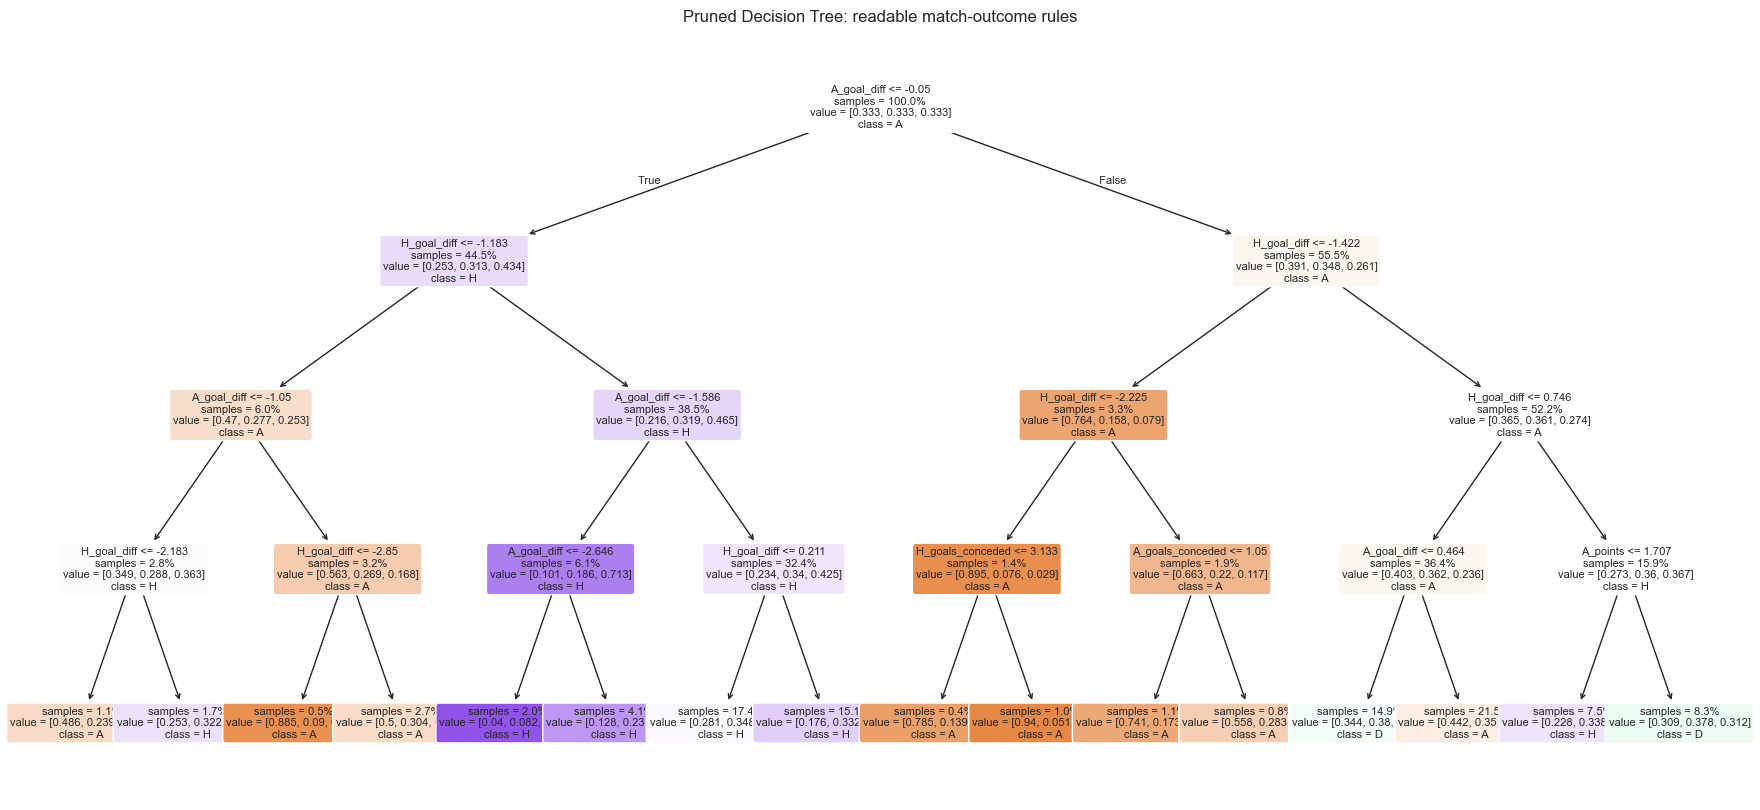

In [23]:
plt.figure(figsize=(22, 10))
plot_tree(
    decision_tree,
    feature_names=tree_feature_names,
    class_names=decision_tree.classes_,
    filled=True,
    rounded=True,
    impurity=False,
    proportion=True,
    fontsize=8,
)
plt.title('Pruned Decision Tree: readable match-outcome rules')
plt.show()


### 6.4. Step 2: Bagging trees

Bagging trains many decision trees on bootstrapped versions of the training set and averages their probabilities. This usually reduces the instability of one tree: a single unusual historical period cannot dominate the full model as easily.


In [24]:
base_bagging_tree = DecisionTreeClassifier(
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)

bagging_kwargs = dict(
    n_estimators=150,
    max_samples=0.8,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

# scikit-learn renamed base_estimator -> estimator. This keeps the notebook compatible with both APIs.
try:
    bagging_model = BaggingClassifier(estimator=base_bagging_tree, **bagging_kwargs)
except TypeError:
    bagging_model = BaggingClassifier(base_estimator=base_bagging_tree, **bagging_kwargs)

bagging_metrics, bagging_pred, bagging_proba = evaluate_classifier('Bagging Trees', bagging_model)
print(f"Out-of-bag accuracy estimate: {bagging_model.oob_score_*100:.2f}%")


Bagging Trees
  Train accuracy: 63.74%
  Test accuracy:  50.43%
  Test log-loss:  0.9961

Classification report on the test set:
              precision    recall  f1-score   support

           H       0.63      0.59      0.61      2282
           D       0.27      0.24      0.25      1101
           A       0.48      0.57      0.52      1436

    accuracy                           0.50      4819
   macro avg       0.46      0.47      0.46      4819
weighted avg       0.50      0.50      0.50      4819

Out-of-bag accuracy estimate: 48.37%


### 6.5. Step 3: Random Forest

Random Forest keeps the bagging idea and adds one more source of diversity: each split only considers a random subset of features. This matters here because many football features are correlated, for example wins, points and goal difference. Random feature selection prevents every tree from using the same strongest variables at the top.


In [25]:
random_forest = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=20,
    max_features='sqrt',
    class_weight='balanced_subsample',
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

rf_metrics, rf_pred, rf_proba = evaluate_classifier('Random Forest', random_forest)
print(f"Out-of-bag accuracy estimate: {random_forest.oob_score_*100:.2f}%")


Random Forest
  Train accuracy: 56.97%
  Test accuracy:  50.24%
  Test log-loss:  0.9988

Classification report on the test set:
              precision    recall  f1-score   support

           H       0.64      0.58      0.61      2282
           D       0.26      0.25      0.26      1101
           A       0.48      0.57      0.52      1436

    accuracy                           0.50      4819
   macro avg       0.46      0.47      0.46      4819
weighted avg       0.51      0.50      0.50      4819

Out-of-bag accuracy estimate: 48.69%


### 6.6. Model comparison

The table below shows the progression from one tree to bagging and finally to Random Forest. The expected pattern is that the single tree is easiest to read, while the ensemble models usually give more stable test performance.


In [26]:
tree_model_comparison = pd.DataFrame([
    {
        'model': 'Majority baseline',
        'train_accuracy': np.nan,
        'test_accuracy': baseline_accuracy,
        'test_log_loss': np.nan,
    },
    dt_metrics,
    bagging_metrics,
    rf_metrics,
])

tree_model_comparison[['train_accuracy', 'test_accuracy']] = tree_model_comparison[['train_accuracy', 'test_accuracy']] * 100

display(
    tree_model_comparison
    .sort_values('test_accuracy', ascending=False)
    .style.format({
        'train_accuracy': '{:.2f}%',
        'test_accuracy': '{:.2f}%',
        'test_log_loss': '{:.4f}',
    }, na_rep='-')
)


,model,train_accuracy,test_accuracy,test_log_loss
2,Bagging Trees,63.74%,50.43%,0.9961
3,Random Forest,56.97%,50.24%,0.9988
1,Decision Tree,49.08%,49.45%,1.0295
0,Majority baseline,-,47.35%,-


### 6.6.1. Why can Bagging be slightly more accurate than Random Forest?

If Bagging Trees gets a higher test accuracy than Random Forest in one run, this is not a contradiction. Random Forest is built from bagging, but it also forces each split to consider only a random subset of features (`max_features='sqrt'`). That extra randomness usually improves robustness and reduces overfitting, especially when there are many noisy or redundant features. In our dataset we only have 18 engineered features, and several of the strongest football indicators are highly informative. Bagging can sometimes benefit from letting every tree use all features at every split, giving slightly higher raw accuracy.

So the process still makes sense: **Decision Tree** gives interpretability, **Bagging** reduces tree variance, and **Random Forest** adds feature-level randomness for a more stable final ensemble. Accuracy is one metric; we also compare log-loss, confusion matrices and feature importance and our objectif is to make random forest model.


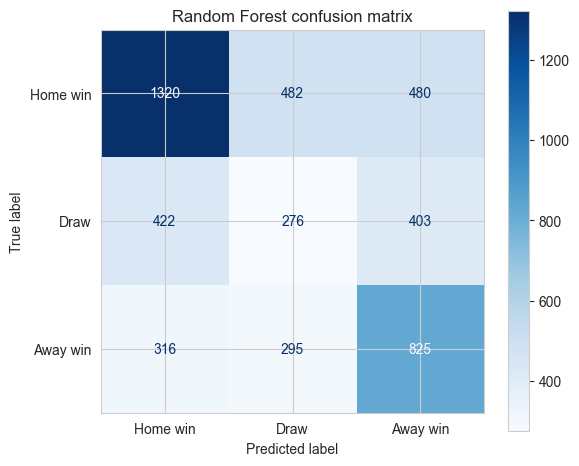

In [38]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_tree,
    rf_pred,
    labels=CLASS_ORDER,
    display_labels=['Home win', 'Draw', 'Away win'],
    cmap='Blues',
    values_format='d',
    ax=ax,
)
ax.set_title('Random Forest confusion matrix')
plt.tight_layout()
plt.show()


### 6.7. Explainability: which features drive the forest?

Random Forest is less transparent than one tree, but it is still explainable at the feature level. We use two complementary views:

- **Impurity importance:** how often and how strongly a feature reduces uncertainty inside the forest.
- **Permutation importance:** how much test accuracy drops when a feature is shuffled. This is slower but closer to real predictive usefulness.


In [28]:
gini_importance = pd.Series(
    random_forest.feature_importances_,
    index=tree_feature_names,
    name='gini_importance',
)

perm = permutation_importance(
    random_forest,
    X_test_tree,
    y_test_tree,
    n_repeats=10,
    scoring='accuracy',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

permutation_importance_df = pd.DataFrame({
    'feature': tree_feature_names,
    'permutation_mean': perm.importances_mean,
    'permutation_std': perm.importances_std,
})

rf_feature_importance = (
    permutation_importance_df
    .merge(gini_importance.reset_index().rename(columns={'index': 'feature'}), on='feature')
    .sort_values('permutation_mean', ascending=False)
    .reset_index(drop=True)
)

display(rf_feature_importance.head(12).style.format({
    'permutation_mean': '{:.4f}',
    'permutation_std': '{:.4f}',
    'gini_importance': '{:.4f}',
}))


,feature,permutation_mean,permutation_std,gini_importance
0,H_goal_diff,0.0212,0.0033,0.1430
1,H_points,0.0087,0.0015,0.0686
2,H_goals_scored,0.0085,0.0016,0.0531
3,H_goals_conceded,0.0082,0.0036,0.1120
4,H_wins,0.0056,0.0017,0.0311
5,is_neutral,0.0047,0.0023,0.0281
6,A_goals_conceded,0.0024,0.0028,0.0976
7,H_draws,0.0024,0.0011,0.0204
8,H_losses,0.0024,0.0017,0.0456
9,is_competitive,0.0021,0.0018,0.0243


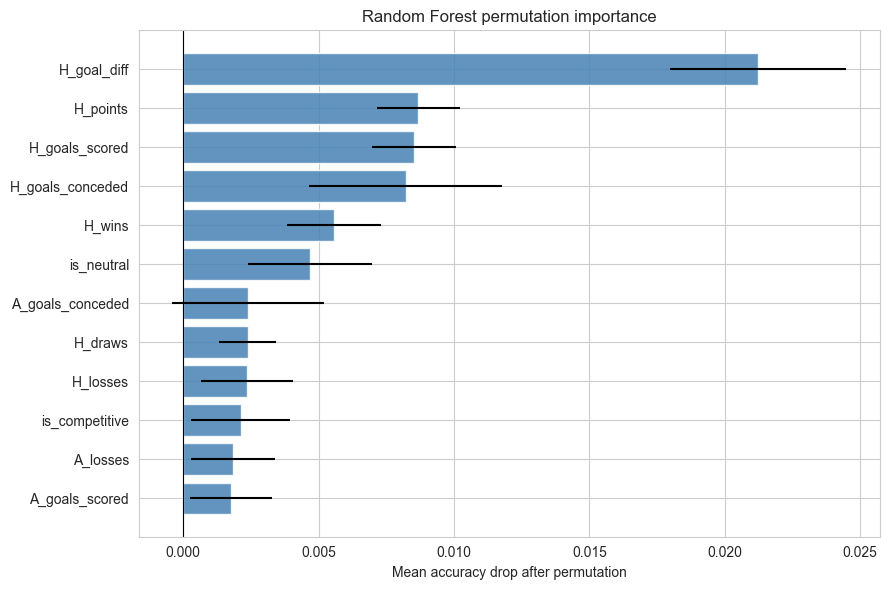

In [29]:
top_features = rf_feature_importance.head(12).sort_values('permutation_mean')

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_features['feature'], top_features['permutation_mean'], xerr=top_features['permutation_std'], color='steelblue', alpha=0.85)
ax.set_xlabel('Mean accuracy drop after permutation')
ax.set_title('Random Forest permutation importance')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


### 6.8. Explain one prediction

For a concrete prediction, we show the class probabilities and the most important feature values for that row. This is not a SHAP-style local decomposition; it is a lightweight, honest explanation that combines the forest's probability output with the globally important variables learned above.


In [30]:
def explain_random_forest_prediction(row_index, model=random_forest, X_data=X_test_tree, y_data=y_test_tree, feature_importance=rf_feature_importance):
    """Explain one test prediction using probabilities and the row's most important feature values."""
    row = X_data.iloc[[row_index]]
    probabilities = pd.Series(model.predict_proba(row)[0], index=model.classes_, name='probability').sort_values(ascending=False)
    predicted_class = probabilities.index[0]
    true_class = y_data.iloc[row_index]

    important_features = feature_importance.head(8)['feature'].tolist()
    feature_view = pd.DataFrame({
        'feature': important_features,
        'match_value': row.iloc[0][important_features].values,
        'permutation_importance': feature_importance.set_index('feature').loc[important_features, 'permutation_mean'].values,
        'gini_importance': feature_importance.set_index('feature').loc[important_features, 'gini_importance'].values,
    })

    print(f"Test row: {row_index}")
    print(f"Predicted result: {predicted_class}")
    print(f"True result:      {true_class}")
    print("\nPredicted probabilities:")
    display(probabilities.to_frame().style.format({'probability': '{:.3f}'}))
    print("\nMost relevant feature values for this prediction:")
    display(feature_view.style.format({
        'match_value': '{:.3f}',
        'permutation_importance': '{:.4f}',
        'gini_importance': '{:.4f}',
    }))

# Example: explain the first match in the test set.
explain_random_forest_prediction(0)


Test row: 0
Predicted result: H
True result:      H

Predicted probabilities:


,probability
H,0.547
D,0.291
A,0.162



Most relevant feature values for this prediction:


,feature,match_value,permutation_importance,gini_importance
0,H_goal_diff,2.000,0.0212,0.1430
1,H_points,2.300,0.0087,0.0686
2,H_goals_scored,2.700,0.0085,0.0531
3,H_goals_conceded,0.700,0.0082,0.1120
4,H_wins,7.000,0.0056,0.0311
5,is_neutral,0.000,0.0047,0.0281
6,A_goals_conceded,1.400,0.0024,0.0976
7,H_draws,2.000,0.0024,0.0204


### 6.9. Live prediction: putting it all together

We now wrap the Random Forest pipeline into one function. Given a home team, an away team and match context, it rebuilds the same 18 features used during training from recent match history, then returns the predicted class probabilities.

This makes the model usable for a new fixture instead of only evaluating rows already present in `X_test`.


In [37]:
def load_rf_match_history(path='../data/results_clean.csv'):
    """Load historical matches with valid scores for live Random Forest predictions."""
    history = pd.read_csv(path)
    history['date'] = pd.to_datetime(history['date'])
    history = history.dropna(subset=['home_score', 'away_score']).copy()
    history['home_score'] = history['home_score'].astype(int)
    history['away_score'] = history['away_score'].astype(int)
    history['neutral'] = history['neutral'].astype(str).str.upper().map({'TRUE': True, 'FALSE': False}).fillna(False).astype(bool)
    history = history[history['date'] >= f"{globals().get('START_YEAR', 2000)}-01-01"]
    return history.sort_values('date').reset_index(drop=True)


def get_rf_team_last_matches(history, team, before_date, n=10):
    """Return the team's last n matches before the reference date."""
    before_date = pd.to_datetime(before_date)
    mask = ((history['home_team'] == team) | (history['away_team'] == team)) & (history['date'] < before_date)
    return history.loc[mask].sort_values('date').tail(n)


def compute_rf_team_stats(history, team):
    """Compute the same recent-form statistics used in the training features."""
    if len(history) == 0:
        return {
            'matches_played': 0,
            'wins': 0,
            'draws': 0,
            'losses': 0,
            'goals_scored': 0.0,
            'goals_conceded': 0.0,
            'goal_diff': 0.0,
            'points': 0.0,
        }

    wins = draws = losses = 0
    goals_scored = goals_conceded = 0

    for _, match in history.iterrows():
        if match['home_team'] == team:
            scored = match['home_score']
            conceded = match['away_score']
        else:
            scored = match['away_score']
            conceded = match['home_score']

        goals_scored += scored
        goals_conceded += conceded

        if scored > conceded:
            wins += 1
        elif scored < conceded:
            losses += 1
        else:
            draws += 1

    n_matches = len(history)
    return {
        'matches_played': n_matches,
        'wins': wins,
        'draws': draws,
        'losses': losses,
        'goals_scored': goals_scored / n_matches,
        'goals_conceded': goals_conceded / n_matches,
        'goal_diff': (goals_scored - goals_conceded) / n_matches,
        'points': (3 * wins + draws) / n_matches,
    }


def build_rf_feature_row(home_team, away_team, neutral=False, competitive=True, reference_date=None, history=None, n_window=10):
    """Build one feature row with the exact columns expected by the Random Forest."""
    if history is None:
        history = load_rf_match_history()
    if reference_date is None:
        reference_date = history['date'].max() + pd.Timedelta(days=1)

    home_history = get_rf_team_last_matches(history, home_team, reference_date, n=n_window)
    away_history = get_rf_team_last_matches(history, away_team, reference_date, n=n_window)

    if len(home_history) == 0:
        raise ValueError(f"No previous matches found for home team: {home_team}")
    if len(away_history) == 0:
        raise ValueError(f"No previous matches found for away team: {away_team}")

    home_stats = compute_rf_team_stats(home_history, home_team)
    away_stats = compute_rf_team_stats(away_history, away_team)

    row = {}
    for key, value in home_stats.items():
        row[f'H_{key}'] = value
    for key, value in away_stats.items():
        row[f'A_{key}'] = value

    row['is_neutral'] = int(neutral)
    row['is_competitive'] = int(competitive)

    return pd.DataFrame([row], columns=tree_feature_names)


def predict_match_random_forest(home_team, away_team, neutral=False, competitive=True, reference_date=None, history=None, model=random_forest, n_window=10):
    """Predict H/D/A probabilities for a new match using the trained Random Forest."""
    feature_row = build_rf_feature_row(
        home_team=home_team,
        away_team=away_team,
        neutral=neutral,
        competitive=competitive,
        reference_date=reference_date,
        history=history,
        n_window=n_window,
    )

    probabilities = pd.Series(model.predict_proba(feature_row)[0], index=model.classes_, name='probability').sort_values(ascending=False)
    prediction = probabilities.index[0]

    print(f"{home_team} vs {away_team}")
    print(f"Predicted result: {prediction}")
    print("\nPredicted probabilities:")
    display(probabilities.to_frame().style.format({'probability': '{:.3f}'}))

    print("\nFeature row used by the model:")
    display(feature_row.T.rename(columns={0: 'value'}).style.format({'value': '{:.3f}'}))

    return prediction, probabilities, feature_row


# Example live prediction. Change the teams and context for another fixture.DR Congo, Portugal
predict_match_random_forest(
    home_team='Belgium',
    away_team='France',
    neutral=True,
    competitive=True,
)

predict_match_random_forest(
    home_team='France',
    away_team='Belgium',
    neutral=True,
    competitive=True,
)

predict_match_random_forest(
    home_team='France',
    away_team='DR Congo',
    neutral=True,
    competitive=True,
)

predict_match_random_forest(
    home_team='DR Congo',
    away_team='Belgium',
    neutral=True,
    competitive=True,
)

predict_match_random_forest(
    home_team='DR Congo',
    away_team='Portugal',
    neutral=True,
    competitive=True,
)

Belgium vs France
Predicted result: A

Predicted probabilities:


,probability
A,0.352
H,0.326
D,0.322



Feature row used by the model:


,value
H_matches_played,10.000
H_wins,6.000
H_draws,4.000
H_losses,0.000
H_goals_scored,3.500
H_goals_conceded,1.000
H_goal_diff,2.500
H_points,2.200
A_matches_played,10.000
A_wins,8.000


France vs Belgium
Predicted result: H

Predicted probabilities:


...

DR Congo vs Portugal
Predicted result: D

Predicted probabilities:


,probability
D,0.394
A,0.368
H,0.238



Feature row used by the model:


,value
H_matches_played,10.000
H_wins,7.000
H_draws,2.000
H_losses,1.000
H_goals_scored,1.200
H_goals_conceded,0.300
H_goal_diff,0.900
H_points,2.300
A_matches_played,10.000
A_wins,6.000


('D',
 D    0.394280
 A    0.368081
 H    0.237639
 Name: probability, dtype: float64,
    H_matches_played  H_wins  H_draws  H_losses  H_goals_scored  \
 0                10       7        2         1             1.2   
 
    H_goals_conceded  H_goal_diff  H_points  A_matches_played  A_wins  A_draws  \
 0               0.3          0.9       2.3                10       6        3   
 
    A_losses  A_goals_scored  A_goals_conceded  A_goal_diff  A_points  \
 0         1             2.6               1.0          1.6       2.1   
 
    is_neutral  is_competitive  
 0           1               1  )

### 6.10. Save Random Forest artifacts

We save the three tree-family models, their comparison table, predictions and feature importances. The final comparison section can load `random_forest_metrics.pkl` exactly like the MLP metrics file.


In [33]:
random_forest_metrics = {
    'accuracy': rf_metrics['test_accuracy'],
    'log_loss': rf_metrics['test_log_loss'],
    'y_true': y_test_tree.to_numpy(),
    'y_pred': rf_pred,
    'y_proba': rf_proba,
    'classes': random_forest.classes_,
    'comparison': tree_model_comparison,
    'feature_importance': rf_feature_importance,
}

joblib.dump(decision_tree, f'{TREE_MODEL_DIR}/decision_tree.pkl')
joblib.dump(bagging_model, f'{TREE_MODEL_DIR}/bagging_trees.pkl')
joblib.dump(random_forest, f'{TREE_MODEL_DIR}/random_forest.pkl')
joblib.dump(random_forest_metrics, f'{TREE_MODEL_DIR}/random_forest_metrics.pkl')

print(f"Saved tree-family models and metrics to '{TREE_MODEL_DIR}/'")


Saved tree-family models and metrics to '../models/RandomForest/'


---
## 7. Model 3: Neural Network

This section implements a Multi-Layer Perceptron (MLP) using PyTorch as our deep learning approach. An MLP can learn arbitrarily complex non-linear relationships between features through stacked layers of nonlinear transformations:

$$f(X) = \text{softmax}(W_3 \cdot \text{ReLU}(W_2 \cdot \text{ReLU}(W_1 \cdot X + b_1) + b_2) + b_3)$$

### 7.1. Create the validation set

We split our data into 3 sets chronologically:

- **Train:** the model learns from these matches
- **Validation:** carved from the end of `X_train` to track overfitting and tune hyperparameters
- **Test:** kept untouched until the final evaluation

In [20]:
val_ratio = 0.1
val_split_idx = int(len(X_train) * (1 - val_ratio))

# keep the most recent 10% of X_train as validation
X_val = X_train.iloc[val_split_idx:].reset_index(drop=True)
X_train = X_train.iloc[:val_split_idx].reset_index(drop=True)

y_val = y_train.iloc[val_split_idx:].reset_index(drop=True)
y_train = y_train.iloc[:val_split_idx].reset_index(drop=True)


print(f"Train/Validation/Test split:")
print(f"  Strict train: {len(X_train)} matches")
print(f"  Validation: {len(X_val)} matches")
print(f"  Test: {len(X_test)} matches")

Train/Validation/Test split:
  Strict train: 17348 matches
  Validation: 1928 matches
  Test: 4819 matches


### 7.2. Standardizing features

Neural networks are very sensitive to feature scale. If one feature ranges from 0 to 1000 and another from 0 to 1, the network's gradient descent will be dominated by the larger feature, making training unstable.

We use `StandardScaler` to transform each feature to **mean = 0** and **standard deviation = 1**:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

We fit on the strict training set only, then apply the same transformation to validation and test sets. This guarantees no information from validation or test leaks into the scaler's statistics.

In [21]:
# show features range before standardization
print(X_train.describe().loc[['mean', 'std']].round(2))

      H_matches_played  H_wins  H_draws  H_losses  H_goals_scored  \
mean              9.91    3.86     2.35      3.71            1.39   
std               0.56    1.95     1.41      2.08            0.64   

      H_goals_conceded  H_goal_diff  H_points  A_matches_played  A_wins  \
mean              1.33         0.05      1.40              9.90    3.75   
std               0.76         1.14      0.57              0.58    1.95   

      A_draws  A_losses  A_goals_scored  A_goals_conceded  A_goal_diff  \
mean     2.33      3.82            1.36              1.38        -0.02   
std      1.42      2.10            0.64              0.82         1.19   

      A_points  is_neutral  is_competitive  
mean      1.37        0.26            0.64  
std       0.57        0.44            0.48  


In [22]:
# apply standardization
scaler = StandardScaler()

# fit on train only
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# show features range after standardization
print(X_train_scaled.describe().loc[['mean', 'std']].round(2))

      H_matches_played  H_wins  H_draws  H_losses  H_goals_scored  \
mean              -0.0     0.0     -0.0       0.0             0.0   
std                1.0     1.0      1.0       1.0             1.0   

      H_goals_conceded  H_goal_diff  H_points  A_matches_played  A_wins  \
mean               0.0          0.0       0.0               0.0     0.0   
std                1.0          1.0       1.0               1.0     1.0   

      A_draws  A_losses  A_goals_scored  A_goals_conceded  A_goal_diff  \
mean     -0.0       0.0            -0.0              -0.0          0.0   
std       1.0       1.0             1.0               1.0          1.0   

      A_points  is_neutral  is_competitive  
mean      -0.0         0.0            -0.0  
std        1.0         1.0             1.0  


### 7.3. Encoding the labels

Our target `y`contains string labels: `'H'`, `'D'` and `'A'`. PyTorch's loss functions require integer labels: `0`, `1` and `2`.

In [23]:
# apply encoding
label_encoder = LabelEncoder()

# fit on train labels only
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded  = label_encoder.transform(y_val)
y_test_encoded  = label_encoder.transform(y_test)

# inspect the mapping
print("Label encoding map:")
for class_label, encoded_value in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"'{class_label}' -> {encoded_value}")

# check if decoded labels match the originals
decoded_sample = label_encoder.inverse_transform(y_train_encoded[:5])
print(f"\nFirst 5 original labels: {y_train.iloc[:5].tolist()}")
print(f"First 5 decoded labels: {decoded_sample.tolist()}")
print(f"Match: {(y_train.iloc[:5].tolist() == decoded_sample.tolist())}")

Label encoding map:
'A' -> 0
'D' -> 1
'H' -> 2

First 5 original labels: ['H', 'A', 'H', 'D', 'D']
First 5 decoded labels: ['H', 'A', 'H', 'D', 'D']
Match: True


### 7.4. Converting to PyTorch tensors

PyTorch works with tensors. We convert our 3 sets into tensors. We then wrap them into `DataLoader`s for mini-batch training: instead of feeding the whole dataset at once, the model sees 64 rows at a time.

In [24]:
X_train_tensor = torch.FloatTensor(X_train_scaled.values)
X_val_tensor = torch.FloatTensor(X_val_scaled.values)
X_test_tensor = torch.FloatTensor(X_test_scaled.values)

y_train_tensor = torch.LongTensor(y_train_encoded)
y_val_tensor = torch.LongTensor(y_val_encoded)
y_test_tensor = torch.LongTensor(y_test_encoded)

# wrap features and labels into a TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

DataLoaders created:
  Train batches: 272
  Val batches: 31
  Test batches: 76


### 7.5. The MLP architecture

For an input vector with our 18 features, out MLP computes:

$$
\begin{aligned}
h_1 &= \text{ReLU}(W_1 x + b_1) \quad \text{(first hidden layer)} \\
h_2 &= \text{ReLU}(W_2 h_1 + b_2) \quad \text{(second hidden layer)} \\
z   &= W_3 h_2 + b_3 \quad \text{(output logits)} \\
\hat{y} &= \text{softmax}(z) \quad \text{(class probabilities)}
\end{aligned}
$$

Where:
- $W_i$, $b_i$ are the trainable parameters (weights and biases)
- $\text{ReLU(x) = max(0, x)}$ is the activation function
- $\text{softmax}$ converts logits into probabilities summing to 1

In [25]:
class MLP(nn.Module):

    def __init__(self, input_size, hidden1, hidden2, output_size, dropout):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, output_size)
        self.dropout = nn.Dropout(p=dropout)

    
    def forward(self, x):
        # first hidden layer
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        # second hidden layer
        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        # output layer
        x = self.fc3(x)

        return x
    

# instantiate the model
model = MLP(input_size=18, hidden1=64, hidden2=32, output_size=3, dropout=0.3)

# count trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")


Total trainable parameters: 3,395


### 7.6. Loss function and optimizer

To train the network, we need two ingredients:

**Loss function (Cross-Entropy):** the standard loss for multi-class classification. It measures how confident the model is about the *correct* class:

$$\mathcal{L}(y, \hat{p}) = -\log(\hat{p}_y)$$

If the model assigns 99% to the right class -> loss ≈ 0.01. If it assigns 5% → loss ≈ 3.0 (heavily penalized).

**Optimizer (Adam):** the standard choice for training neural networks. Unlike standard SGD, Adam adapts the learning rate per parameter and incorporates momentum, which leads to faster and more stable convergence. We use the conventional default `lr=1e-3` together with a small `weight_decay=1e-5` for L2 regularization.

In [26]:
# hyperparameters
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5 # L2 regularization

# loss function: Cross-Entropy for multi-class classification
criterion = nn.CrossEntropyLoss()

# optimizer: Adam
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

### 7.7. The training loop anatomy

Training means iteratively updating the weights to minimize the loss. Each full pass through the dataset is one epoch.

For every mini-batch, we perform 5 steps:
1. **Forward pass:** feed the batch through the model
2. **Loss computation:** compare predictions to ground truth
3. **Backward pass:** compute gradients
4. **Optimizer step:** update the weights
5. **Reset gradients:** clear the buffer for the next batch

After each epoch, we evaluate on the validation set to monitor overfitting.

In [27]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train() # activate dropout
    total_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        # forward pass
        logits = model(X_batch)

        # compute loss
        loss = criterion(logits, y_batch)

        # backward pass (compute gradients)
        optimizer.zero_grad() # reset previous gradients
        loss.backward()

        # optimizer step (update weights)
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total   += X_batch.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


def evaluate(model, loader, criterion):

    model.eval() # deactivate dropout
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total   += X_batch.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    
    return avg_loss, accuracy


N_EPOCHS = 100
history = {"train_loss": [], "val_loss": [], "train_acc":  [], "val_acc":  []}

for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

print("Training complete !")
print(f"Best val accuracy: {max(history['val_acc']):.3f} (epoch {history['val_acc'].index(max(history['val_acc'])) + 1})")

Training complete !
Best val accuracy: 0.559 (epoch 17)


### 7.8. Visualizing the learning dynamics

We plot the four tracked metrics:

1. **Train loss** vs **Validation loss**: should both decrease together
2. **Train accuracy** vs **Validation accuracy**: should both increase together

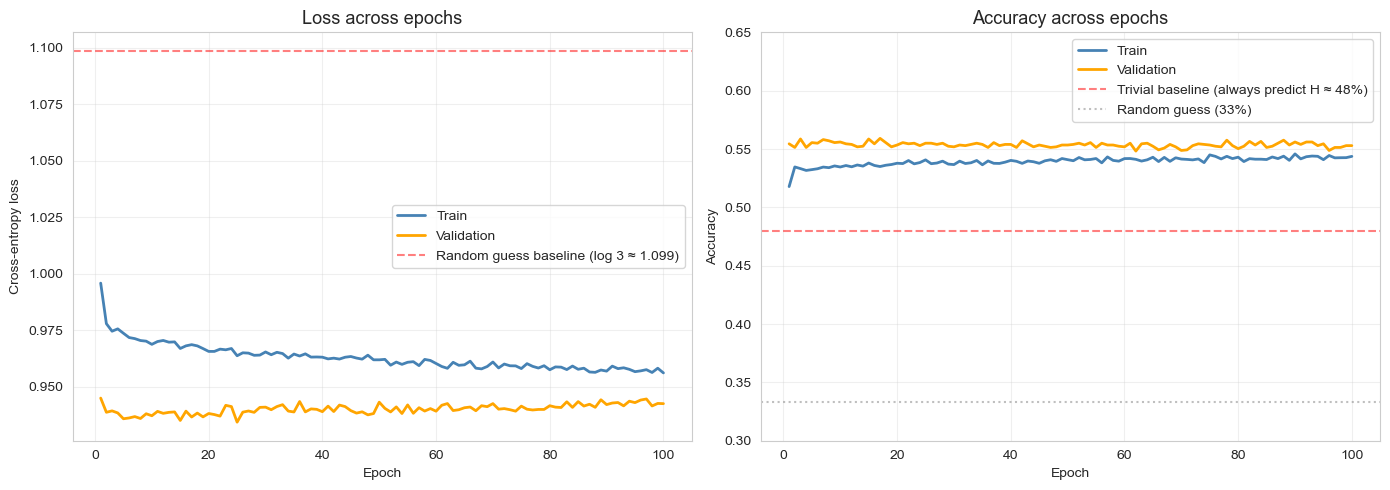

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# loss curves
axes[0].plot(epochs_range, history['train_loss'], label='Train', color='steelblue', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   label='Validation', color='orange', linewidth=2)
axes[0].axhline(np.log(3), color='red', linestyle='--', alpha=0.5, label=f'Random guess baseline (log 3 ≈ {np.log(3):.3f})')
axes[0].set_title('Loss across epochs', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# accuracy curves
axes[1].plot(epochs_range, history['train_acc'], label='Train', color='steelblue', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'],   label='Validation', color='orange', linewidth=2)
axes[1].axhline(0.48, color='red', linestyle='--', alpha=0.5, label='Trivial baseline (always predict H ≈ 48%)')
axes[1].axhline(1/3, color='gray', linestyle=':', alpha=0.5, label='Random guess (33%)')
axes[1].set_title('Accuracy across epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.30, 0.65)

plt.tight_layout()
plt.show()

### 7.9. Final evaluation on the test set

We now evaluate the model on the test set, untouched until this point. This provides an unbiased estimate of generalization to unseen matches.

In [29]:
# get predictions on the test set
model.eval()

all_logits = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch)
        all_logits.append(logits)
        all_labels.append(y_batch)

# concatenate all batches
all_logits = torch.cat(all_logits, dim=0)
all_labels = torch.cat(all_labels, dim=0)

# convert to predictions and probabilities
y_pred_encoded = all_logits.argmax(dim=1).numpy()
y_proba = F.softmax(all_logits, dim=1).numpy()
y_true_encoded = all_labels.numpy()

# decode labels back to H/D/A
y_pred = label_encoder.inverse_transform(y_pred_encoded)
y_true = label_encoder.inverse_transform(y_true_encoded)

# compute the two metrics
accuracy = accuracy_score(y_true, y_pred)
test_log_loss = log_loss(y_true_encoded, y_proba)

print(f"MLP performance on the test set ({len(y_true)} matches)")
print(f"  Accuracy: {accuracy*100:.2f}% (vs 33% random baseline)")
print(f"  Log-loss: {test_log_loss:.4f} (vs log(3) ≈ {np.log(3):.4f} random)")

# save metrics for the final comparison section
mlp_metrics = {
    'accuracy': accuracy,
    'log_loss': test_log_loss,
    'y_true': y_true,
    'y_pred': y_pred,
    'y_proba': y_proba
}

MLP performance on the test set (4819 matches)
  Accuracy: 54.80% (vs 33% random baseline)
  Log-loss: 0.9642 (vs log(3) ≈ 1.0986 random)


### 7.10. Saving the trained model

We save the model weights and preprocessing artifacts.

In [30]:
MODEL_DIR = '../models/MLP'
os.makedirs(MODEL_DIR, exist_ok=True)

torch.save(model.state_dict(), f"{MODEL_DIR}/mlp_weights.pt")
joblib.dump(scaler, f"{MODEL_DIR}/scaler.pkl")
joblib.dump(label_encoder, f"{MODEL_DIR}/label_encoder.pkl")
joblib.dump(mlp_metrics, f"{MODEL_DIR}/mlp_metrics.pkl")

['../models/MLP/mlp_metrics.pkl']

### 7.11 Live prediction: putting it all together

We wrap the entire pipeline into a single function `predict_match(home_team, away_team, ...)` that automates everything: history retrieval, feature computation, standardization, forward pass, calibrated probabilities. This is what a deployed system looks like in practice — and it will also be used in Section 9 to simulate the entire 2026 World Cup.

In [42]:
def predict_match(home_team, away_team, neutral=False, competitive=True, reference_date=None, df_history=None, model=model, scaler=scaler, label_encoder=label_encoder, n_window=10):
    """Predict the outcome of a match between two teams."""
    if df_history is None:
        df_history = df
    if reference_date is None:
        reference_date = pd.Timestamp.now()

    # Get each team's recent history
    home_history = get_team_last_matches(df_history, home_team, reference_date, n=n_window)
    away_history = get_team_last_matches(df_history, away_team, reference_date, n=n_window)

    if len(home_history) < 5 or len(away_history) < 5:
        return {'error': f"Insufficient history for {home_team} or {away_team}"}

    # Compute rolling stats
    home_stats = compute_team_stats(home_history, home_team)
    away_stats = compute_team_stats(away_history, away_team)

    # Build the feature vector in the EXACT order of FEATURE_COLS
    feature_dict = {}
    for key, val in home_stats.items():
        feature_dict[f'H_{key}'] = val
    for key, val in away_stats.items():
        feature_dict[f'A_{key}'] = val
    feature_dict['is_neutral'] = int(neutral)
    feature_dict['is_competitive'] = int(competitive)

    features = np.array([feature_dict[col] for col in FEATURE_COLS]).reshape(1, -1)

    # Standardize and forward pass
    features_scaled = scaler.transform(features)
    model.eval()
    with torch.no_grad():
        logits = model(torch.FloatTensor(features_scaled))
        probas = F.softmax(logits, dim=1).numpy()[0]

    classes = label_encoder.classes_
    proba_dict = {f'P({c})': float(probas[i]) for i, c in enumerate(classes)}

    return {
        'home_team': home_team,
        'away_team': away_team,
        'context': {'neutral': neutral, 'competitive': competitive},
        'home_form': f"{home_stats['wins']}W-{home_stats['draws']}D-{home_stats['losses']}L",
        'away_form': f"{away_stats['wins']}W-{away_stats['draws']}D-{away_stats['losses']}L",
        'probabilities': proba_dict,
        'predicted': classes[probas.argmax()],
        'confidence': float(probas.max())
    }


def display_prediction(result):
    """Pretty-print a prediction dictionary."""
    if 'error' in result:
        print(f"⚠️  {result['error']}")
        return

    label_full = {'H': 'Home win', 'D': 'Draw', 'A': 'Away win'}

    # build context tag
    venue = "neutral ground" if result['context']['neutral'] else "home advantage"
    stakes = "competitive" if result['context']['competitive'] else "friendly"

    print(f"⚽ {result['home_team']}  vs  {result['away_team']}")
    print(f"   Context: {stakes} match, {venue}")
    print(f"   Recent form: {result['home_team']} {result['home_form']}, "
          f"{result['away_team']} {result['away_form']}")
    print(f"   Probabilities:")
    for class_name in ['H', 'D', 'A']:
        key = f'P({class_name})'
        bar = '█' * int(result['probabilities'][key] * 30)
        print(f"     {class_name} ({label_full[class_name]:<10}): "
              f"{result['probabilities'][key]*100:5.1f}%  {bar}")
    print(f"   -> Prediction: {label_full[result['predicted']]}  ")
    print()


# DEMO: predict 3 hypothetical matches
print("Live predictions on hypothetical matches\n")
display_prediction(predict_match('France', 'Belgium'))
display_prediction(predict_match('Brazil', 'Argentina'))
display_prediction(predict_match('Germany', 'Spain', neutral=True, competitive=False))

Live predictions on hypothetical matches

⚽ France  vs  Belgium
   Context: competitive match, home advantage
   Recent form: France 8W-1D-1L, Belgium 6W-4D-0L
   Probabilities:
     H (Home win  ):  43.6%  █████████████
     D (Draw      ):  23.1%  ██████
     A (Away win  ):  33.2%  █████████
   -> Prediction: Home win  

⚽ Brazil  vs  Argentina
   Context: competitive match, home advantage
   Recent form: Brazil 5W-2D-3L, Argentina 8W-1D-1L
   Probabilities:
     H (Home win  ):  32.9%  █████████
     D (Draw      ):  29.1%  ████████
     A (Away win  ):  38.1%  ███████████
   -> Prediction: Away win  

⚽ Germany  vs  Spain
   Context: friendly match, neutral ground
   Recent form: Germany 7W-0D-3L, Spain 7W-3D-0L
   Probabilities:
     H (Home win  ):  31.7%  █████████
     D (Draw      ):  28.5%  ████████
     A (Away win  ):  39.8%  ███████████
   -> Prediction: Away win  



/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


---
## 8. Final comparison of the three models
TO DO